## Data preparation

In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
 ADNI_preparation.ipynb      model
 cbir			     preprocessing
 CBIR.ipynb		     README.md
 CBIR_wholeBrain.ipynb	     seg_preparation.ipynb
 CBIR_wholeBrain_SVF.ipynb   subcortical_AE_training.ipynb
 compute_SVF.ipynb	    'subcortical_SVF_training .ipynb'
 data			     training
 global_AE_training.ipynb    utils
 global_SVF_training.ipynb


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [3]:
import sys
print(sys.executable)


/usr/bin/python3


In [4]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

In [5]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_UINT/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
raw_labels = np.array([get_label(image_id, labels_df) for image_id in raw_image_ids]).astype('float32')
raw_ages = np.array([get_label(image_id, labels_df, column='age_at_visit') for image_id in raw_image_ids]).astype('float32')
raw_ids = np.array([get_label(image_id, labels_df, column='OASISID') for image_id in raw_image_ids])

# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages = raw_ages[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)

/home/maia-user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2681,) (2680,)


In [6]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths=image_paths, labels=labels, ages=ages, ids=ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1852 - IR: 0.20
Validation samples: 372 - IR: 0.21
Testing samples: 456 - IR: 0.26


In [7]:
from preprocessing.load_dataset import StratifiedBatchSampler
import torchio as tio

batch_size = 24  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])

# Preparing the dataset to feed the network
train_dataset = BrainMRIDataset(train_set['image_paths'], train_set['ages'], train_set['labels'], 
                                transform=None, transform_age=3, cache=False, sparse_path=None)
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = BrainMRIDataset(val_set['image_paths'], val_set['ages'], val_set['labels'], cache=False, sparse_path=None)
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainMRIDataset(test_set['image_paths'], test_set['ages'], test_set['labels'], cache=False, sparse_path=None)
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)

In [8]:
dataset = BrainMRIDataset(image_paths, ages, labels,
                          transform=None, transform_age=3, cache=False, sparse_path=None)

In [9]:
from model.autoencoder import Conv3DSparseAutoencoder

# Load dataset features
dataset_feats = pd.DataFrame(list(np.load("./data/dataset_feats_20250503_153007.npy", allow_pickle=True)))

In [10]:
import torch
import torch.nn as nn

def group_norm(channels):
    if channels >= 32:
        return nn.GroupNorm(8, channels)
    elif channels >= 16:
        return nn.GroupNorm(4, channels)
    else:
        return nn.GroupNorm(2, channels)

def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1, norm=True, activation=True, dropout=None):
    layers = [nn.Conv3d(in_channels, out_channels, kernel_size, stride, padding)]
    if norm:
        layers.append(group_norm(out_channels))
    if activation:
        layers.append(nn.ReLU(inplace=True))
    if dropout is not None:
        layers.append(nn.Dropout3d(dropout))
    return nn.Sequential(*layers)

def deconv_block(in_channels, out_channels, kernel_size=3, stride=2, padding=0, output_padding=0, norm=True, activation=True):
    layers = [nn.ConvTranspose3d(in_channels, out_channels, kernel_size, stride, padding, output_padding)]
    if norm:
        layers.append(group_norm(out_channels))
    if activation:
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


class Conv3DAutoencoder(nn.Module):
    def __init__(self, input_shape=(1, 176, 208, 160), bottleneck_dim=64):
        super().__init__()
        self.input_shape = input_shape

        # Encoder
        self.encoder_conv = nn.Sequential(
            conv_block(1, 32, kernel_size=4, stride=2, padding=1, dropout=0.1),
            conv_block(32, 24, kernel_size=4, stride=2, padding=1, dropout=0.1),
            conv_block(24, 16, kernel_size=4, stride=2, padding=1),
            conv_block(16, 8, kernel_size=4, stride=2, padding=1),
        )

        # # Determine shape after encoder
        # with torch.no_grad():
        #     dummy = torch.zeros((1, *input_shape))
        #     conv_out = self.encoder_conv(dummy)
        #     self.conv_shape = conv_out.shape[1:]
        #     self.flat_dim = conv_out.numel() // conv_out.shape[0]

        # # Bottleneck
        # self.encoder_fc = nn.Linear(self.flat_dim, bottleneck_dim)
        # self.decoder_fc = nn.Linear(bottleneck_dim, self.flat_dim)

        # Decoder
        self.decoder_conv = nn.Sequential(
            deconv_block(8, 16, kernel_size=4, padding=1, output_padding=0),
            deconv_block(16, 24, kernel_size=4, padding=1, output_padding=0),
            deconv_block(24, 32, kernel_size=4, padding=1, output_padding=0),
            deconv_block(32, 1, kernel_size=4, padding=1, output_padding=0, norm=False, activation=False),
        )

    def forward(self, x):
        z = self.encoder_conv(x)
        # x = torch.flatten(x, start_dim=1)
        # z = self.encoder_fc(x)

        # x = self.decoder_fc(z)
        # x = x.view(-1, *self.conv_shape)
        x_out = self.decoder_conv(z)

        return z, x_out


# Load model
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bottleneck_dim=64
autoencoder = Conv3DAutoencoder(bottleneck_dim=bottleneck_dim).to(device)
pretrained_param = torch.load('./data/pretrained_models/CP_20250503_153007.pth')
autoencoder.load_state_dict(pretrained_param)

<All keys matched successfully>

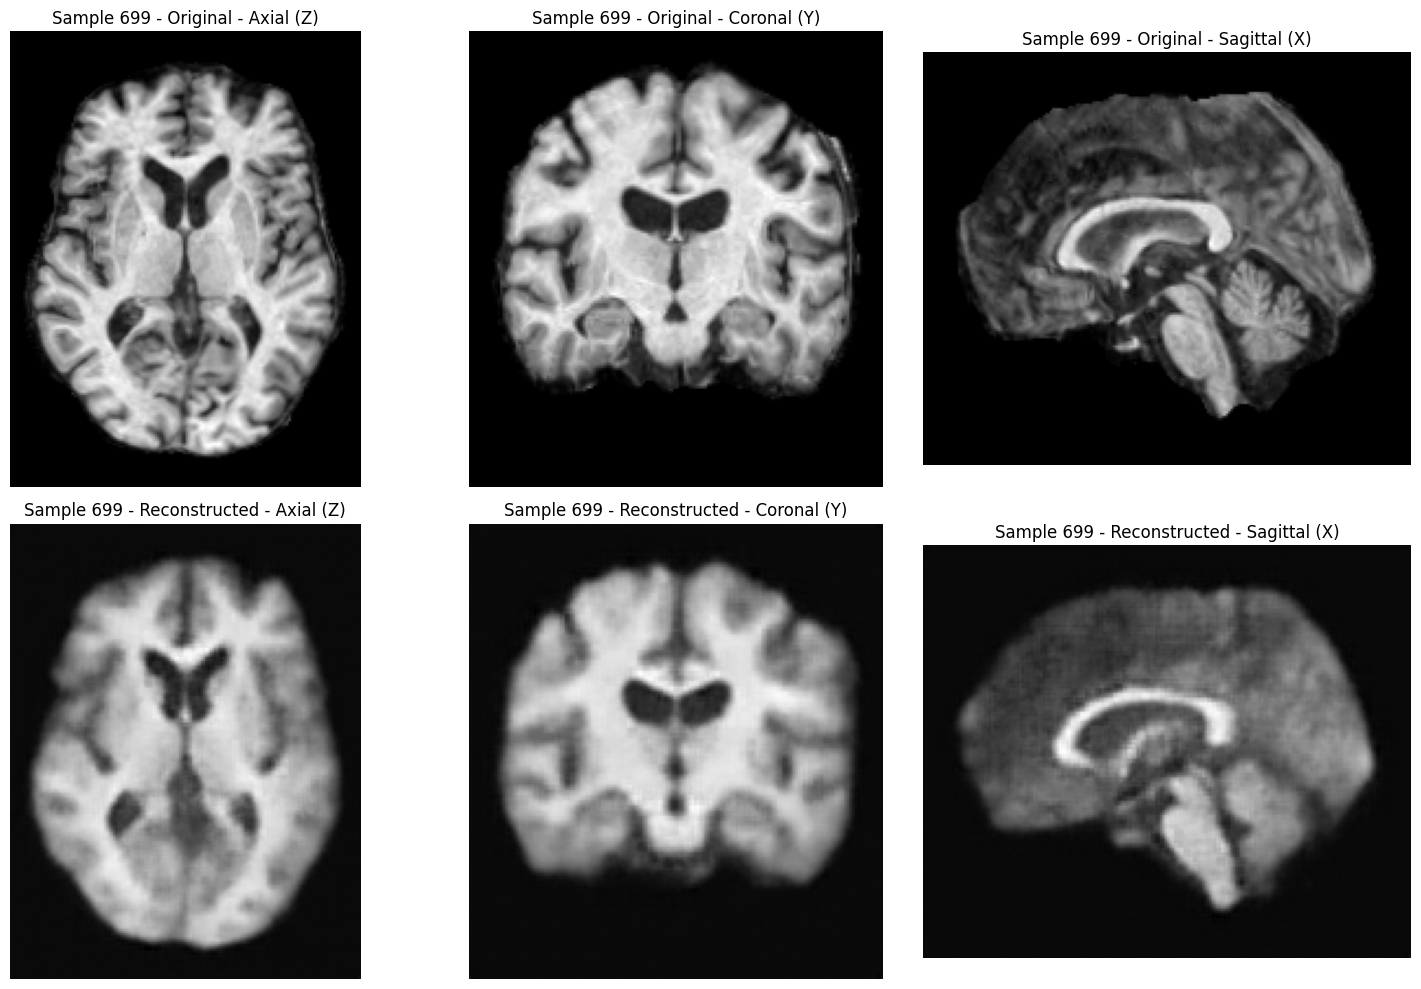

In [11]:
from utils.visualization import visualize_autoencoder_reconstruction

sample_1 = dataset[699]
visualize_autoencoder_reconstruction(autoencoder, sample_1, device, substructure_index=0, title_prefix="Sample 699 - ")

In [12]:
subc_str = 'whole_brain'
dataset_feats.query(f"subc_str == '{subc_str}'")

,subject_id,record_id,subc_str,label,age,features
0,OAS30647,OAS30647_MR_d0232,whole_brain,0.0,55.165615,"[0.12394133, 0.1533015, 0.1533015, 0.1533015, ..."
1,OAS31405,OAS31405_MR_d0149,whole_brain,0.0,56.018219,"[0.13124014, 0.16122876, 0.16122876, 0.1612287..."
2,OAS30901,OAS30901_MR_d0155,whole_brain,1.0,65.804657,"[0.15832135, 0.22200309, 0.22200309, 0.2220030..."
3,OAS30534,OAS30534_MR_d3728,whole_brain,0.0,76.703697,"[0.123958886, 0.15213089, 0.15213089, 0.152130..."
4,OAS30120,OAS30120_MR_d0784,whole_brain,1.0,85.837944,"[0.17828237, 0.2514625, 0.2514625, 0.2514625, ..."
...,...,...,...,...,...,...
2674,OAS31031,OAS31031_MR_d0069,whole_brain,0.0,60.419041,"[0.15529332, 0.20919383, 0.20919383, 0.2091938..."
2675,OAS30818,OAS30818_MR_d1720,whole_brain,0.0,74.772331,"[0.17907356, 0.2582004, 0.2582004, 0.2582004, ..."
2676,OAS30235,OAS30235_MR_d1175,whole_brain,0.0,60.679176,"[0.13179164, 0.16460519, 0.16460519, 0.1646051..."
2677,OAS30846,OAS30846_MR_d0160,whole_brain,0.0,59.018356,"[0.06168176, 0.06655663, 0.06655663, 0.0665566..."


In [13]:
np.stack(dataset_feats['label'].values)

array([0., 0., 1., ..., 0., 0., 1.])

## Embedding 2d representation

/home/maia-user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/maia-user/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


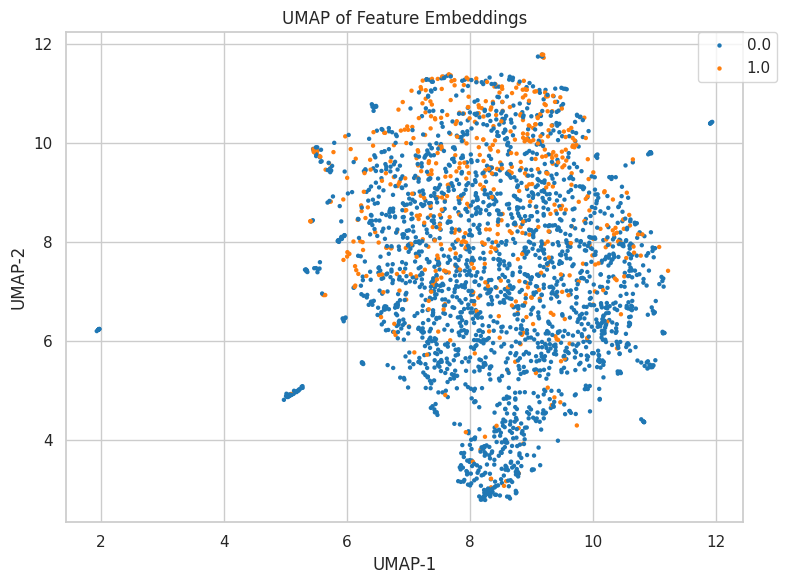

In [ ]:
from cbir.projection import compute_umap_embeddings, plot_projection

# Let's say you have a feature matrix and optional labels
features = np.stack(dataset_feats['features'].values)
labels = np.stack(dataset_feats['label'].values)

embedding = compute_umap_embeddings(features)
plot_projection(embedding, labels=labels, title="UMAP of Feature Embeddings")


## Retrieve k-cases example

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
from cbir.feature_engineering import prepare_dataset_with_combined_features

def evaluation_function_classification(query_class, top_k_classes):
    hits = np.sum(top_k_classes == query_class)
    return hits

def retrieve_top_k(i_query, dataset, top_k=3, class_column='class_label', evaluation_function=None):

    hits_at_k = 0
    hits_at_least_one = 0
    total_queries = 0
    total_retrieved = 0

    features_matrix = np.stack(dataset['features'].values)

    # for i in range(len(dataset)):
    query = dataset.iloc[i_query]
    query_class = query[class_column]
    features = query['features'].reshape(1, -1)

    # Check if there are enough records of this class
    class_records = dataset[dataset[class_column] == query_class]
    if len(class_records)+1 < top_k:
        print(f"N = {len(class_records)}.Not enough similar scans for that subject")  # Skip if not enough records of this class

    similarities = cosine_similarity(features, features_matrix)[0]
    similarities[i_query] = -1  # Exclude self

    top_k_indices = np.argsort(similarities)[::-1][:top_k]
    # top_k_indices = np.argsort(similarities)[::-1][-top_k-2:-2]
    top_k_classes = dataset.iloc[top_k_indices][class_column].values

    # Evaluation
    hits = evaluation_function(query_class, top_k_classes)
    if hits > 0:
        hits_at_least_one += 1
    hits_at_k += hits

    total_queries += 1
    total_retrieved += top_k

    print(f"Precision@{top_k} = {hits_at_k/top_k}")

    top_k_hits = top_k_classes == query_class
    print(top_k_hits)

    return top_k_indices, top_k_hits

# subc_strs = ['Hippocampus (lh)'] #0
subc_strs = ['whole_brain'] #-2


i_query = -1
top_k = 5
combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
top_k_mri, top_k_hits = retrieve_top_k(i_query, combined_dataset, top_k=top_k, class_column='subject_id', evaluation_function=evaluation_function_classification)

N = 1.Not enough similar scans for that subject
Precision@5 = 0.0
[False False False False False]


(176, 208, 160)


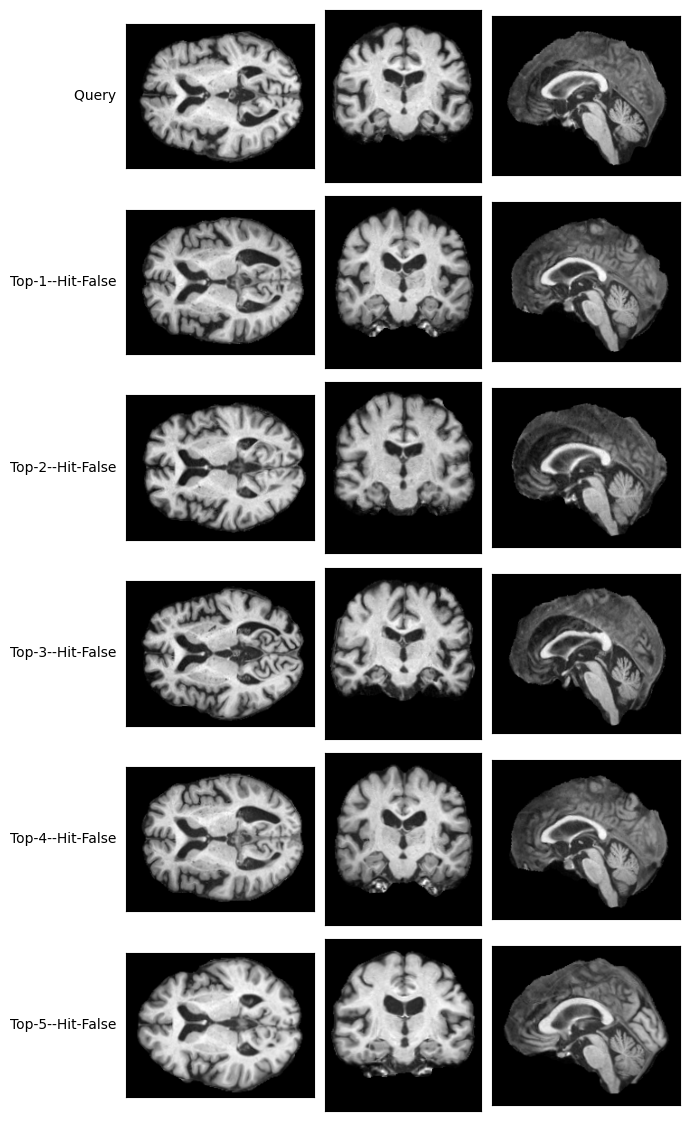

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mri_slices(mri_data, row_title=None, fig=None, row_idx=0):
    """
    Plots axial, coronal, sagittal views in a single row of subplots.
    """
    axial = mri_data[mri_data.shape[0] // 2, :, :]
    coronal = np.flip(mri_data[:, mri_data.shape[1] // 2, :].T, axis=1)
    sagittal = np.flip(mri_data[:, :, mri_data.shape[2] // 2].T, axis=1)

    views = [axial, coronal, sagittal]
    # titles = ['Axial', 'Coronal', 'Sagittal']
    titles = ['', '', '']

    for i, (view, title) in enumerate(zip(views, titles)):
        ax = fig.axes[row_idx * 3 + i]
        ax.imshow(view.T, cmap="gray", origin="lower")
        ax.set_xticks([])
        ax.set_yticks([])
        # ax.axis("off")
        # if row_title:
        #     ax.set_title(f"{row_title} {title}", fontsize=10)
        if i == 0:
            label = ax.set_ylabel(f"{row_title} {title}", fontsize=10, rotation=0)
            label.set_horizontalalignment('right')  # Align text to left
            label.set_verticalalignment('center')  # Vertically center
            label.set_position((-0.1, 0.5))       

def visualize_query_and_retrieved(dataset, i_query, top_k_mri, top_k_hits, combined_dataset, title="Query vs Top-K Retrieved"):
    num_rows = 1 + len(top_k_mri)
    fig, axes = plt.subplots(num_rows, 3, figsize=(7, 2 * num_rows))
    fig.subplots_adjust(hspace=0.2)

    # Query
    record_id = combined_dataset.reset_index().iloc[i_query].record_id
    i_dataset_query = np.where([record_id in p for p in dataset.image_paths])[0][0]
    mri_query = dataset[i_dataset_query]['input'][0].numpy()
    print(mri_query.shape)
    plot_mri_slices(mri_query, "Query", fig, 0)

    # Retrieved
    for row_idx, (k_mri_i, hit) in enumerate(zip(top_k_mri, top_k_hits), start=1):
        record_id = combined_dataset.reset_index().iloc[k_mri_i].record_id
        i_dataset = np.where([record_id in p for p in dataset.image_paths])[0][0]
        mri_data = dataset[i_dataset]['input'][0].numpy()
        plot_mri_slices(mri_data, f"Top-{row_idx}--Hit-{hit}", fig, row_idx)

    # fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()


visualize_query_and_retrieved(dataset, i_query, top_k_mri, top_k_hits, combined_dataset)

## Intra-subject evaluation

In [14]:
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

# Example usage
subc_strs = ['whole_brain']
top_k = 1

combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="subject_id")

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

KeyboardInterrupt: 

In [16]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

results = []
list_subc_strs = [
    ['whole_brain'],
]

list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="subject_id")

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))
    

Evaluating combinations: 100%|██████████| 3/3 [11:04<00:00, 221.49s/it]

╒══════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures   │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞══════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ whole_brain  │       1 │        0.9448 │      0.9448 │                2011 │
├──────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ whole_brain  │       3 │        0.9197 │      0.982  │                 946 │
├──────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ whole_brain  │       5 │        0.8701 │      0.9799 │                 348 │
╘══════════════╧═════════╧═══════════════╧═════════════╧═════════════════════╛


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Abbreviations
structure_abbr = {
    'whole_brain': 'WB',
}

def abbreviate_structures(structure_str):
    if len(structure_str.split(', ')) >= 10:
        return 'all'
    return '+'.join([structure_abbr.get(s.strip(), s) for s in structure_str.split(', ')])

df = pd.DataFrame(results)
df['Abbr Structures'] = df['Structures'].apply(abbreviate_structures)

# Plotting
sns.set(style="whitegrid")
unique_k = sorted(df['Top-K'].unique())

for k in unique_k:
    df_k = df[df['Top-K'] == k].sort_values(by='Precision@K', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, max(4, 0.2 * len(df_k))), sharey=True)

    for i, metric in enumerate(['Precision@K', 'Success@K']):
        sns.barplot(
                    data=df_k,
                    y='Abbr Structures',
                    x=metric,
                    ax=axes[i],
                    hue='Abbr Structures',
                    dodge=False,
                    legend=False,
                    palette='Set2'
                )
        axes[i].set_xlim([0, 1])


    plt.suptitle(f'Retrieval Metrics at Top-{k}')
    plt.tight_layout()
    plt.show()




AttributeError: 'set' object has no attribute 'get'

## Evaluation class-level

In [ ]:
# from cbir.feature_engineering import prepare_dataset_with_combined_features
# from cbir.evaluation import evaluate_similarity_retrieval

# # Example usage
# subc_strs = ['whole_brain']
# top_k = 3

# combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
# metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="label")

# print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
# print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@3: 0.8233
Success@3: 0.9518


In [ ]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

results = []
list_subc_strs = [
    ['whole_brain']
]

list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="label")

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))
    

Evaluating combinations: 100%|██████████| 48/48 [09:37<00:00, 12.02s/it]

╒════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures                                                                                                                                             │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ Hippocampus (lh)                                                                                                                                       │       1 │        0.8611 │      0.8611 │                2679 │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

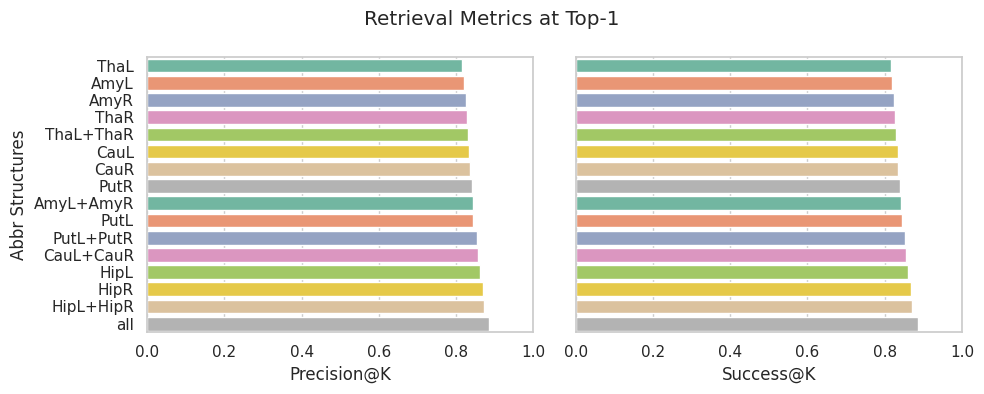

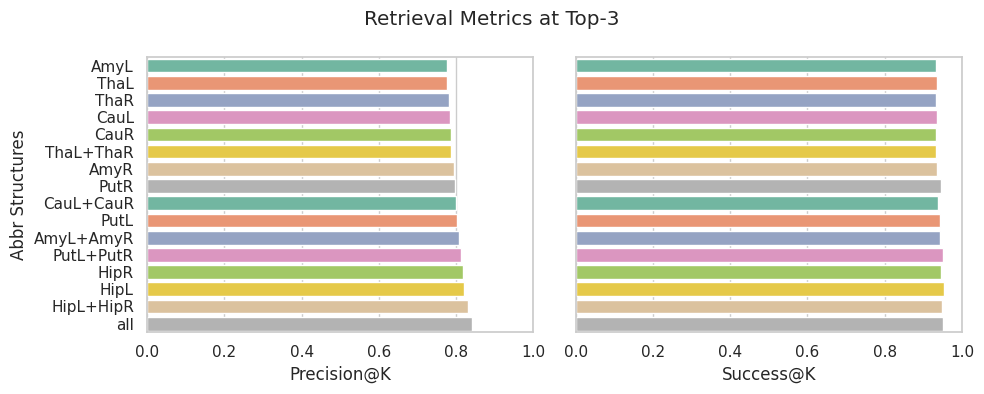

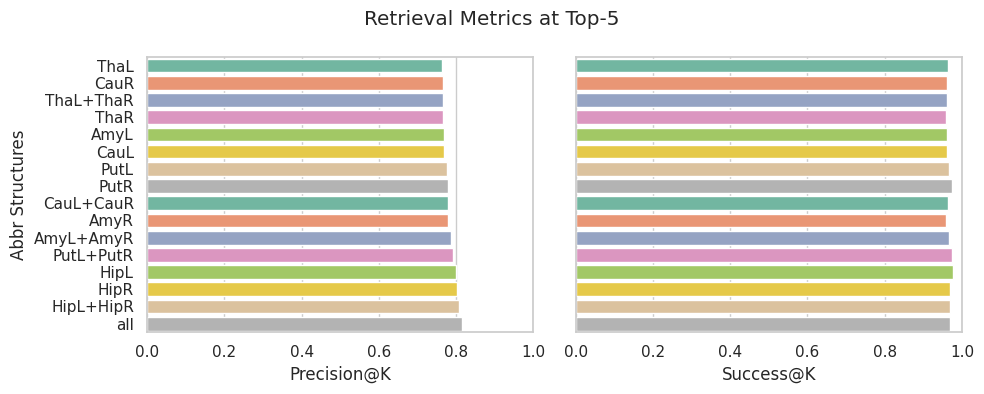

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Abbreviations
structure_abbr = {
    'whole_brain': 'WB',
}

def abbreviate_structures(structure_str):
    if len(structure_str.split(', ')) >= 10:
        return 'all'
    return '+'.join([structure_abbr.get(s.strip(), s) for s in structure_str.split(', ')])

df = pd.DataFrame(results)
df['Abbr Structures'] = df['Structures'].apply(abbreviate_structures)

# Plotting
sns.set(style="whitegrid")
unique_k = sorted(df['Top-K'].unique())

for k in unique_k:
    df_k = df[df['Top-K'] == k].sort_values(by='Precision@K', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, max(4, 0.2 * len(df_k))), sharey=True)

    for i, metric in enumerate(['Precision@K', 'Success@K']):
        sns.barplot(
                    data=df_k,
                    y='Abbr Structures',
                    x=metric,
                    ax=axes[i],
                    hue='Abbr Structures',
                    dodge=False,
                    legend=False,
                    palette='Set2'
                )
        axes[i].set_xlim([0, 1])


    plt.suptitle(f'Retrieval Metrics at Top-{k}')
    plt.tight_layout()
    plt.show()
